# 02 — Exploratory Data Analysis
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

Working from `data/wnba_draft_clean.csv` (1,064 picks, 1997–2022). This notebook answers
the descriptive questions the project spec calls out directly, and sets up the visual
vocabulary (colors, styles) reused in later notebooks.

Note: player **position** is not available in this dataset, so all analysis here is
positionless — a real limitation acknowledged up front rather than worked around.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

# WNBA-adjacent palette: orange (league brand) + navy, kept muted for a report feel
COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'
COLOR_GREY = '#9AA5B1'

df = pd.read_csv('../data/wnba_draft_clean.csv')
df.shape


(1064, 29)

## How many picks never played a WNBA game?

In [2]:
never_played_rate = df['never_played'].mean()
print(f"{df['never_played'].sum()} of {len(df)} picks ({never_played_rate:.1%}) never played a WNBA game.")
print()
by_era = df.groupby('draft_era')['never_played'].mean()
print("Never-played rate by era:")
print(by_era.round(3))


334 of 1064 picks (31.4%) never played a WNBA game.

Never-played rate by era:
draft_era
1997-2002: Founding Era         0.268
2003-2009: Contraction Era      0.309
2010-2015: Stabilization Era    0.352
2016-2022: Modern Era           0.345
Name: never_played, dtype: float64


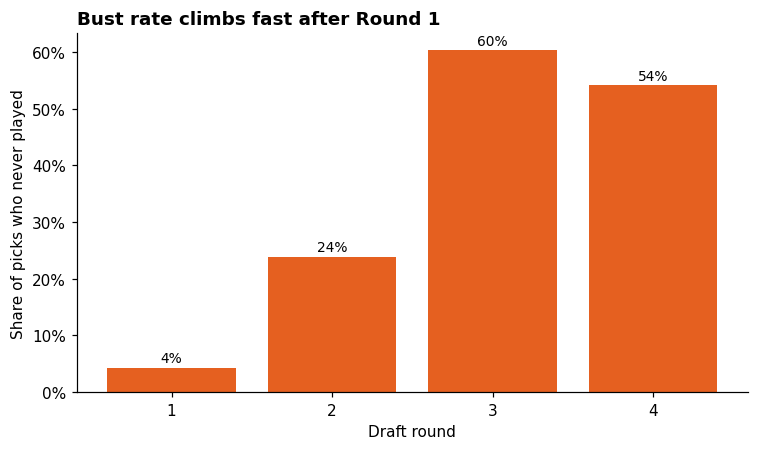

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))
by_round = df.groupby('round')['never_played'].mean()
by_round = by_round[by_round.index <= 4]  # rounds 5 are a tiny 2-pick anomaly, exclude for clarity
bars = ax.bar(by_round.index.astype(str), by_round.values, color=COLOR_MAIN)
ax.set_ylabel('Share of picks who never played')
ax.set_xlabel('Draft round')
ax.set_title('Bust rate climbs fast after Round 1', loc='left', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for b, v in zip(bars, by_round.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../dashboard/chart_never_played_by_round.png', dpi=150, bbox_inches='tight')
plt.show()


## Career length and career games (among those who played)

In [4]:
played = df[~df['never_played']]
print("Career length (years played), players who appeared in at least one game:")
print(played['years_played'].describe().round(2))
print()
print("Career games:")
print(played['games'].describe().round(1))
print()
print("Career win shares:")
print(played['win_shares'].describe().round(2))


Career length (years played), players who appeared in at least one game:
count    730.00
mean       4.51
std        3.78
min        1.00
25%        1.00
50%        3.00
75%        6.00
max       19.00
Name: years_played, dtype: float64

Career games:
count    730.0
mean     116.1
std      118.5
min        1.0
25%       24.0
50%       70.0
75%      172.2
max      580.0
Name: games, dtype: float64

Career win shares:
count    730.00
mean       6.12
std       11.89
min       -2.70
25%        0.00
50%        1.00
75%        6.50
max       93.70
Name: win_shares, dtype: float64


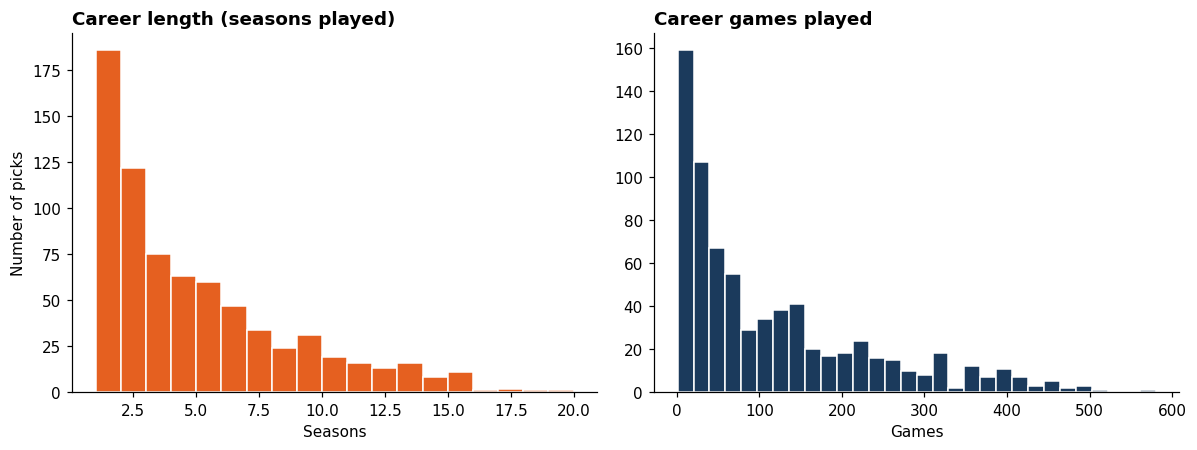

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(played['years_played'], bins=range(1, 21), color=COLOR_MAIN, edgecolor='white')
axes[0].set_title('Career length (seasons played)', loc='left', fontweight='bold')
axes[0].set_xlabel('Seasons')
axes[0].set_ylabel('Number of picks')

axes[1].hist(played['games'], bins=30, color=COLOR_ALT, edgecolor='white')
axes[1].set_title('Career games played', loc='left', fontweight='bold')
axes[1].set_xlabel('Games')

plt.tight_layout()
plt.savefig('../dashboard/chart_career_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Draft pick distributions

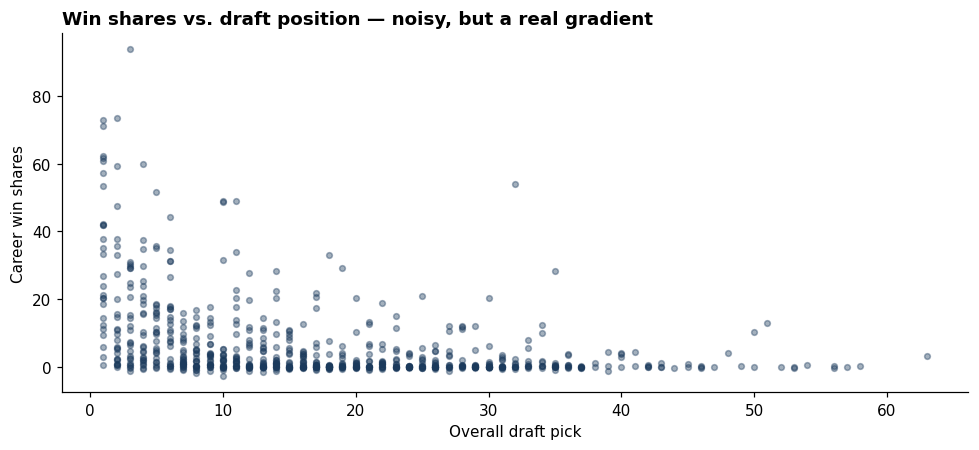

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(df['overall_pick'], df['win_shares'], s=14, alpha=0.4, color=COLOR_ALT)
ax.set_xlabel('Overall draft pick')
ax.set_ylabel('Career win shares')
ax.set_title('Win shares vs. draft position — noisy, but a real gradient', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_pick_vs_winshares.png', dpi=150, bbox_inches='tight')
plt.show()


## Top schools

In [7]:
top_schools_by_picks = df['college_display'].value_counts().head(15)
top_schools_by_picks


college_display
UConn         43
Tennessee     42
Stanford      28
Duke          25
Georgia       24
Baylor        24
Rutgers       21
UNC           21
LSU           20
Notre Dame    20
Maryland      19
Florida       18
Texas         17
Texas A&M     17
NC State      16
Name: count, dtype: int64

In [8]:
# Which schools' picks actually produced WNBA value, not just volume?
school_value = (df[~df['is_international']]
                 .groupby('college_display')
                 .agg(picks=('player', 'count'),
                      avg_win_shares=('win_shares', 'mean'),
                      total_win_shares=('win_shares', 'sum'))
                 .query('picks >= 5')
                 .sort_values('total_win_shares', ascending=False)
                 .head(15))
school_value.round(2)


,picks,avg_win_shares,total_win_shares
college_display,,,
UConn,43,12.50,512.4
Tennessee,42,9.77,351.6
Duke,24,9.21,175.0
Stanford,28,6.84,164.2
LSU,20,10.04,160.7
Rutgers,21,10.09,151.3
Notre Dame,20,8.78,149.2
Maryland,19,9.46,141.9
UNC,21,6.41,108.9


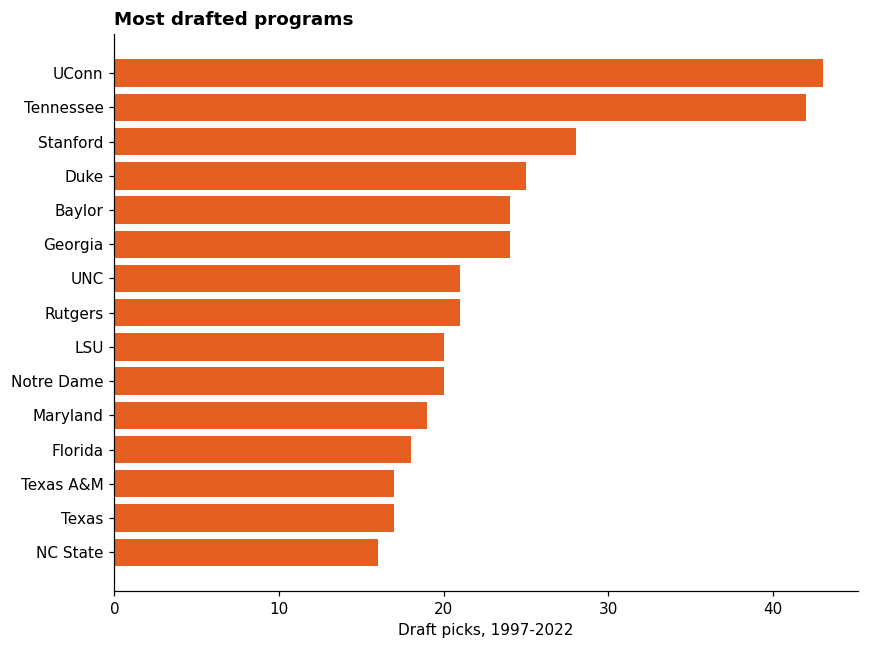

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
order = top_schools_by_picks.sort_values()
ax.barh(order.index, order.values, color=COLOR_MAIN)
ax.set_xlabel('Draft picks, 1997-2022')
ax.set_title('Most drafted programs', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_top_schools.png', dpi=150, bbox_inches='tight')
plt.show()


## International trends

In [10]:
intl_by_era = df.groupby('draft_era')['is_international'].mean()
print("International share of picks by era:")
print(intl_by_era.round(3))
print()
top_countries = df[df['is_international']]['former'].str.extract(r'\(([^)]+)\)$')[0].fillna(df[df['is_international']]['former'])
print("Top international sources (country or club-as-listed):")
print(top_countries.value_counts().head(10))


International share of picks by era:
draft_era
1997-2002: Founding Era         0.086
2003-2009: Contraction Era      0.043
2010-2015: Stabilization Era    0.093
2016-2022: Modern Era           0.095
Name: is_international, dtype: float64

Top international sources (country or club-as-listed):
0
Australia         20
Russia            10
France             9
Spain              9
Poland             3
Slovakia           3
Brazil             3
Hungary            3
Czech Republic     2
Belgium            2
Name: count, dtype: int64


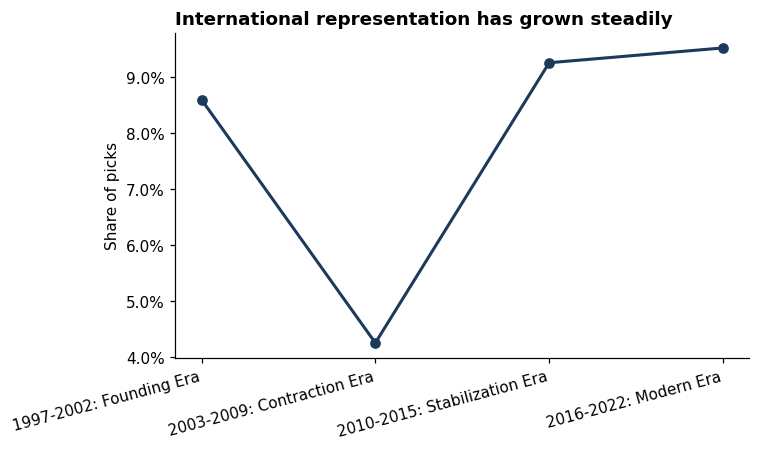

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(intl_by_era.index, intl_by_era.values, marker='o', color=COLOR_ALT, linewidth=2)
ax.set_ylabel('Share of picks')
ax.set_title('International representation has grown steadily', loc='left', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../dashboard/chart_international_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## Career longevity by round

In [12]:
longevity = df.groupby('round').agg(
    picks=('player', 'count'),
    never_played_rate=('never_played', 'mean'),
    avg_years_played=('years_played', 'mean'),
    avg_games=('games', 'mean'),
    avg_win_shares=('win_shares', 'mean'),
).query('picks >= 10')
longevity.round(2)


,picks,never_played_rate,avg_years_played,avg_games,avg_win_shares
round,,,,,
1,325,0.04,5.98,171.94,11.11
2,326,0.24,2.66,83.80,2.79
3,324,0.60,1.07,58.63,1.83
4,85,0.54,1.38,63.23,1.57


## Summary of descriptive findings

- **~31%** of all draft picks (1997-2022) never appeared in a WNBA game — this "bust rate"
  rises sharply after Round 1 and is highest in the modern era's deeper bench of picks.
- Among players who did play, the median career is short: **3 seasons**, ~70 games.
  A long tail of 10+ year careers exists but is rare.
- Draft position correlates with career value but the relationship is **noisy** — there's
  real spread at every pick, which is exactly what Phase 3 (draft value curve) and
  Phase 4 (steal/bust scoring) are built to quantify.
- A handful of programs (UConn, Tennessee, Stanford, Notre Dame) dominate both **pick volume**
  and **total win shares produced** — worth separating "produces picks" from "produces value"
  in Phase 3+.
- International representation has grown across every era of the league's history.
